# EDA

## Load Data
First, let's load cleaned data from csv files and take a look at the columns in these datasets. There are 158 columns (include id) in each datasets. 

In [104]:
import pandas as pd
diamond1 = pd.read_csv("match_data_diamond1.csv")
diamond2 = pd.read_csv("match_data_diamond2.csv")
diamond3 = pd.read_csv("match_data_diamond3.csv")
diamond4 = pd.read_csv("match_data_diamond4.csv")
emerald1 = pd.read_csv("match_data_emerald1.csv")
diamond1.head()

,win,matchId,p1_team,p1_champ,p1_position,p1_gold_per_min,p1_xp_per_min,p1_cs_per_min,p1_dmg_taken_per_min,p1_gold_10min,...,kills_200,kill_diff,first_blood_team100,jungle_own_100,jungle_enemy_100,jungle_own_200,jungle_enemy_200,jungle_invade_diff,gold_diff_10min,xp_diff_10min
0,0,NA1_5464658841,100,Singed,TOP,287.887034,485.794207,8.330361,393.316980,3092,...,5,2,0,2,1,1,0,1,718,991
1,1,NA1_5489233670,100,Zaahen,TOP,318.550809,536.138983,8.663881,518.783083,3368,...,10,-8,0,0,0,0,1,-1,-3030,-979
2,0,NA1_5502986727,100,TahmKench,TOP,275.224109,421.576945,5.441959,435.425418,2978,...,10,-4,0,0,0,0,2,-2,-2231,-8
3,0,NA1_5505235731,100,Aurora,TOP,264.225423,481.457067,7.441384,448.217034,2879,...,5,-2,0,0,0,1,3,-3,-1372,-1826
4,1,NA1_5508890187,100,Singed,TOP,313.886565,419.624587,8.108151,579.323450,3326,...,4,-1,1,2,2,0,0,2,1047,405


In [105]:
feature_list =  []
for f in diamond1.columns:
    feature_list.append(f)
print(feature_list)

['win', 'matchId', 'p1_team', 'p1_champ', 'p1_position', 'p1_gold_per_min', 'p1_xp_per_min', 'p1_cs_per_min', 'p1_dmg_taken_per_min', 'p1_gold_10min', 'p1_cs_10min', 'p1_xp_10min', 'p1_kills_10min', 'p1_deaths_10min', 'p1_assists_10min', 'p1_damage_10min', 'p2_team', 'p2_champ', 'p2_position', 'p2_gold_per_min', 'p2_xp_per_min', 'p2_cs_per_min', 'p2_dmg_taken_per_min', 'p2_gold_10min', 'p2_cs_10min', 'p2_xp_10min', 'p2_kills_10min', 'p2_deaths_10min', 'p2_assists_10min', 'p2_damage_10min', 'p3_team', 'p3_champ', 'p3_position', 'p3_gold_per_min', 'p3_xp_per_min', 'p3_cs_per_min', 'p3_dmg_taken_per_min', 'p3_gold_10min', 'p3_cs_10min', 'p3_xp_10min', 'p3_kills_10min', 'p3_deaths_10min', 'p3_assists_10min', 'p3_damage_10min', 'p4_team', 'p4_champ', 'p4_position', 'p4_gold_per_min', 'p4_xp_per_min', 'p4_cs_per_min', 'p4_dmg_taken_per_min', 'p4_gold_10min', 'p4_cs_10min', 'p4_xp_10min', 'p4_kills_10min', 'p4_deaths_10min', 'p4_assists_10min', 'p4_damage_10min', 'p5_team', 'p5_champ', 'p5_po

There are two types of features in these datasets. One type is for individual player stats, the other type is for team stats. It is necassary to distinguish them before doing EDA.
The match id is included in both datasets for analysis purpose.

In [106]:
def split_data(dataset):
    # all datasets have same column structure, so hard code works here
    player_info_index_start = 0     
    player_info_index_end = 141
    player_info_columns = feature_list[player_info_index_start:player_info_index_end]

    team_info1_index_end = 2    # exclude id
    team_info2_index_start = 142
    team_info_columns = feature_list[:team_info1_index_end] + feature_list[team_info2_index_start:]

    player_dataset = dataset[player_info_columns]
    team_dataset = dataset[team_info_columns]

    return player_dataset, team_dataset

d1_player, d1_team = split_data(diamond1)
d2_player, d2_team = split_data(diamond2)
d3_player, d3_team = split_data(diamond3)
d4_player, d4_team = split_data(diamond4)
e1_player, e1_team = split_data(emerald1)

d1_player.head()


,win,matchId,p1_team,p1_champ,p1_position,p1_gold_per_min,p1_xp_per_min,p1_cs_per_min,p1_dmg_taken_per_min,p1_gold_10min,...,p10_gold_per_min,p10_xp_per_min,p10_cs_per_min,p10_dmg_taken_per_min,p10_gold_10min,p10_cs_10min,p10_xp_10min,p10_kills_10min,p10_deaths_10min,p10_assists_10min
0,0,NA1_5464658841,100,Singed,TOP,287.887034,485.794207,8.330361,393.316980,3092,...,202.559944,241.799065,0.888580,375.535792,2324,8,2177,0,2,2
1,1,NA1_5489233670,100,Zaahen,TOP,318.550809,536.138983,8.663881,518.783083,3368,...,288.425805,361.849429,1.999312,339.435053,3097,18,3258,1,0,5
2,0,NA1_5502986727,100,TahmKench,TOP,275.224109,421.576945,5.441959,435.425418,2978,...,280.858425,305.765606,1.554876,498.755182,3029,14,2753,1,1,5
3,0,NA1_5505235731,100,Aurora,TOP,264.225423,481.457067,7.441384,448.217034,2879,...,255.679317,293.424786,1.333117,273.774585,2802,12,2642,1,1,2
4,1,NA1_5508890187,100,Singed,TOP,313.886565,419.624587,8.108151,579.323450,3326,...,201.374949,268.122912,0.999480,219.164809,2313,9,2414,0,1,2


In [107]:
d1_team.head()

,win,matchId,team100_kills_10min,team200_kills_10min,team100_deaths_10min,team200_deaths_10min,kill_diff_10min,kills_100,kills_200,kill_diff,first_blood_team100,jungle_own_100,jungle_enemy_100,jungle_own_200,jungle_enemy_200,jungle_invade_diff,gold_diff_10min,xp_diff_10min
0,0,NA1_5464658841,7,5,5,7,2,7,5,2,0,2,1,1,0,1,718,991
1,1,NA1_5489233670,2,10,10,2,-8,2,10,-8,0,0,0,0,1,-1,-3030,-979
2,0,NA1_5502986727,6,10,10,6,-4,6,10,-4,0,0,0,0,2,-2,-2231,-8
3,0,NA1_5505235731,3,5,5,3,-2,3,5,-2,0,0,0,1,3,-3,-1372,-1826
4,1,NA1_5508890187,3,4,4,3,-1,3,4,-1,1,2,2,0,0,2,1047,405


## Player Stats

Reshape the table.

In [108]:
import pandas as pd

def reshape_player_data(df):
    player_dfs = []

    for i in range(1, 11):
        prefix = f"p{i}_"
        player_cols = [col for col in df.columns if col.startswith(prefix)]

        temp = df[["win", "matchId"] + player_cols].copy()
        temp.columns = ["win", "matchId"] + [col.replace(prefix, "") for col in player_cols]
        temp["player_num"] = i
        temp["team"] = "team1" if i <= 5 else "team2"

        player_dfs.append(temp)

    player_long = pd.concat(player_dfs, ignore_index=True)
    player_long["win"] = player_long["win"].astype("category")
    player_long["team"] = player_long["team"].astype("category")
    player_long["position"] = player_long["position"].astype("category")
    player_long = player_long.sort_values(["matchId", "player_num"]).reset_index(drop=True)

    return player_long
d1_player =  reshape_player_data(d1_player)
d2_player =  reshape_player_data(d2_player)
d3_player =  reshape_player_data(d3_player)
d4_player =  reshape_player_data(d4_player)
e1_player =  reshape_player_data(e1_player)
d1_player.head()

,win,matchId,team,champ,position,gold_per_min,xp_per_min,cs_per_min,dmg_taken_per_min,gold_10min,cs_10min,xp_10min,kills_10min,deaths_10min,assists_10min,damage_10min,player_num
0,1,LA1_1699272858,team1,Jayce,TOP,263.014533,440.387227,6.664294,368.003640,2868,60,3965,0,1,0,4637.0,1
1,1,LA1_1699272858,team1,Vi,JUNGLE,283.005253,386.317639,7.552961,451.229939,3048,68,3478,0,0,0,730.0,2
2,1,LA1_1699272858,team1,Aurora,MIDDLE,301.881008,543.896003,7.663667,503.139158,3218,69,4897,1,1,0,3710.0,3
3,1,LA1_1699272858,team1,Jinx,BOTTOM,283.554657,348.647354,8.774406,137.736180,3053,79,3139,0,0,0,1345.0,4
4,1,LA1_1699272858,team1,Lulu,UTILITY,174.701637,312.778672,1.221697,299.928635,2073,11,2816,0,1,0,1850.0,5


In [109]:
d1_player.shape

(39660, 17)

merge them into a large dataset to explore differences between ranks

In [110]:
d1 = d1_player.copy()
d2 = d2_player.copy()
d3 = d3_player.copy()
d4 = d4_player.copy()
e1 = e1_player.copy()
    
d1["rank"] = "diamond1"
d2["rank"] = "diamond2"
d3["rank"] = "diamond3"
d4["rank"] = "diamond4"
e1["rank"] = "emerald1"
    
combined = pd.concat([d1, d2, d3, d4, e1], ignore_index=True)
    
rank_order = ["emerald1", "diamond4", "diamond3", "diamond2", "diamond1"]
combined["rank"] = pd.Categorical(combined["rank"], categories=rank_order, ordered=True)

In [111]:
combined.shape

(194640, 18)

### Stats for xp, gold, and cs

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import math

def plot_rank_position_metrics(
    df,
    metrics,
    titles=None,
    scale_cols=None,
    figsize_per_plot=(6, 4)
):
    temp = df.copy()
    
    if scale_cols is not None:  # for dmg taken
        for col, factor in scale_cols.items():
            temp[col] = temp[col] * factor
    
    # group data by rank and position
    summary = (
        temp
        .groupby(["rank", "position"])[metrics]
        .mean()
        .round(2)
        .reset_index()
    )
    

    rank_order = ["diamond4", "diamond3", "diamond2", "diamond1", "emerald1"]
    role_order = ["TOP", "JUNGLE", "MIDDLE", "BOTTOM", "UTILITY"]
    
    summary["rank"] = pd.Categorical(summary["rank"], categories=rank_order, ordered=True)
    summary["position"] = pd.Categorical(summary["position"], categories=role_order, ordered=True)
    summary = summary.sort_values(["rank", "position"]).reset_index(drop=True)
    
    if titles is None:
        titles = metrics
    
    position_colors = {
        "TOP": "tab:blue",
        "JUNGLE": "tab:green",
        "MIDDLE": "tab:red",
        "BOTTOM": "tab:orange",
        "UTILITY": "tab:purple"
    }
    
    n_metrics = len(metrics)
    ncols = 3
    nrows = math.ceil(n_metrics / ncols)
    # plot
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows)
    )
    
    if n_metrics == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    bar_width = 0.15
    x = range(len(rank_order))
    # individual bar for each position, each rank, and each column
    for ax, metric, title in zip(axes, metrics, titles):
        for i, pos in enumerate(role_order):
            pos_data = summary[summary["position"] == pos]
            ax.bar(
                [j + i * bar_width for j in x],
                pos_data[metric],
                width=bar_width,
                label=pos,
                color=position_colors[pos]
            )
        
        ax.set_xticks([j + 2 * bar_width for j in x])
        ax.set_xticklabels(rank_order, rotation=45)
        ax.set_title(title)
        ax.set_xlabel("Rank")
        ax.set_ylabel("Average")
    
    for i in range(n_metrics, len(axes)):
        axes[i].axis("off")
    
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="Position",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )
    
    plt.tight_layout(rect=[0, 0, 0.99, 1])
    plt.show()
    
    return summary

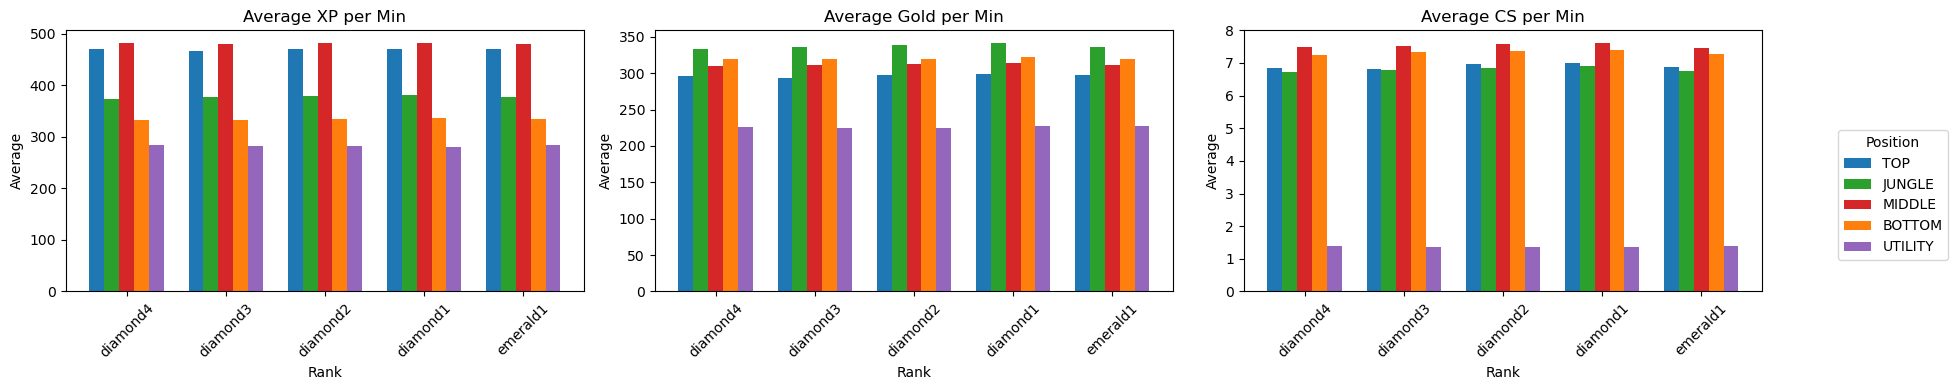

In [113]:
summary1 = plot_rank_position_metrics(
    combined,
    metrics=["xp_per_min", "gold_per_min", "cs_per_min"],
    titles=["Average XP per Min", "Average Gold per Min", "Average CS per Min"]
)

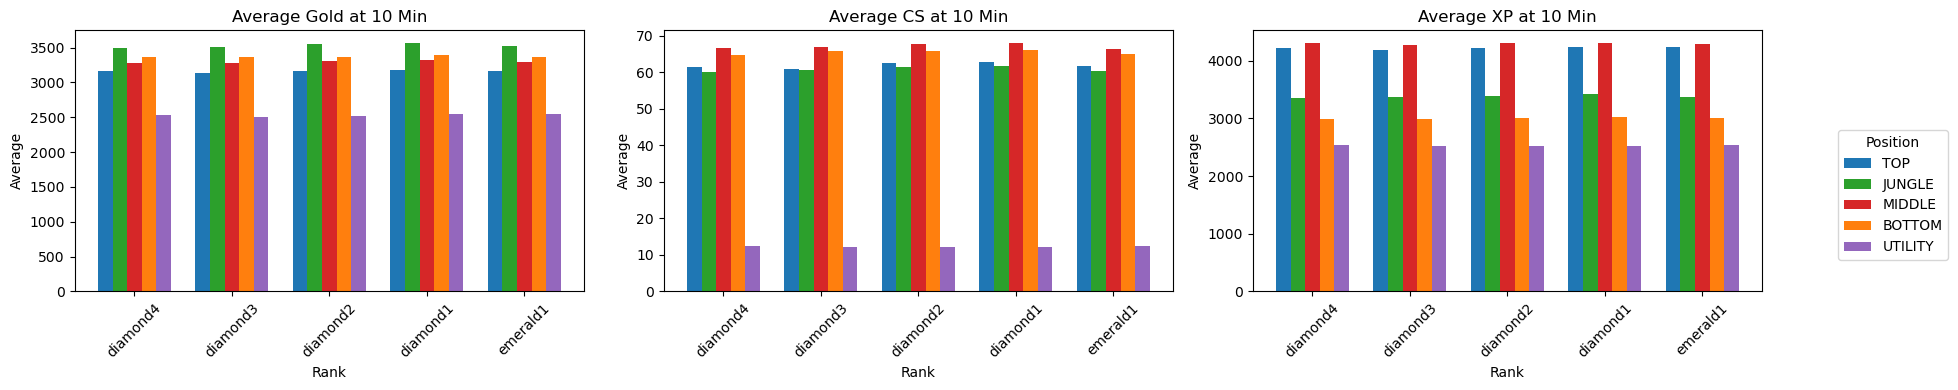

In [114]:
summary2 = plot_rank_position_metrics(
    combined,
    metrics=["gold_10min", "cs_10min", "xp_10min"],
    titles=["Average Gold at 10 Min", "Average CS at 10 Min", "Average XP at 10 Min"]
)

These plots show that player performance varies much more by position than by rank. Across all five ranks, MIDDLE and TOP consistently have the highest average XP per minute, likely because they usually play alone in their lanes and can absorb experience without sharing. In contrast, UTILITY has the lowest XP per minute, since supports typically share lane experience with BOTTOM and may also lose some experience while roaming or rotating across the map. For gold per minute, JUNGLE tends to be the highest, followed by BOTTOM and MIDDLE, while UTILITY again remains the lowest for similar reasons. In terms of CS per minute, MIDDLE and BOTTOM are generally the strongest, whereas UTILITY is far below every other role. Overall, these patterns remain very stable across ranks, suggesting that role-based differences are much stronger than rank-based differences for these three early-game metrics.

### Stats for other data

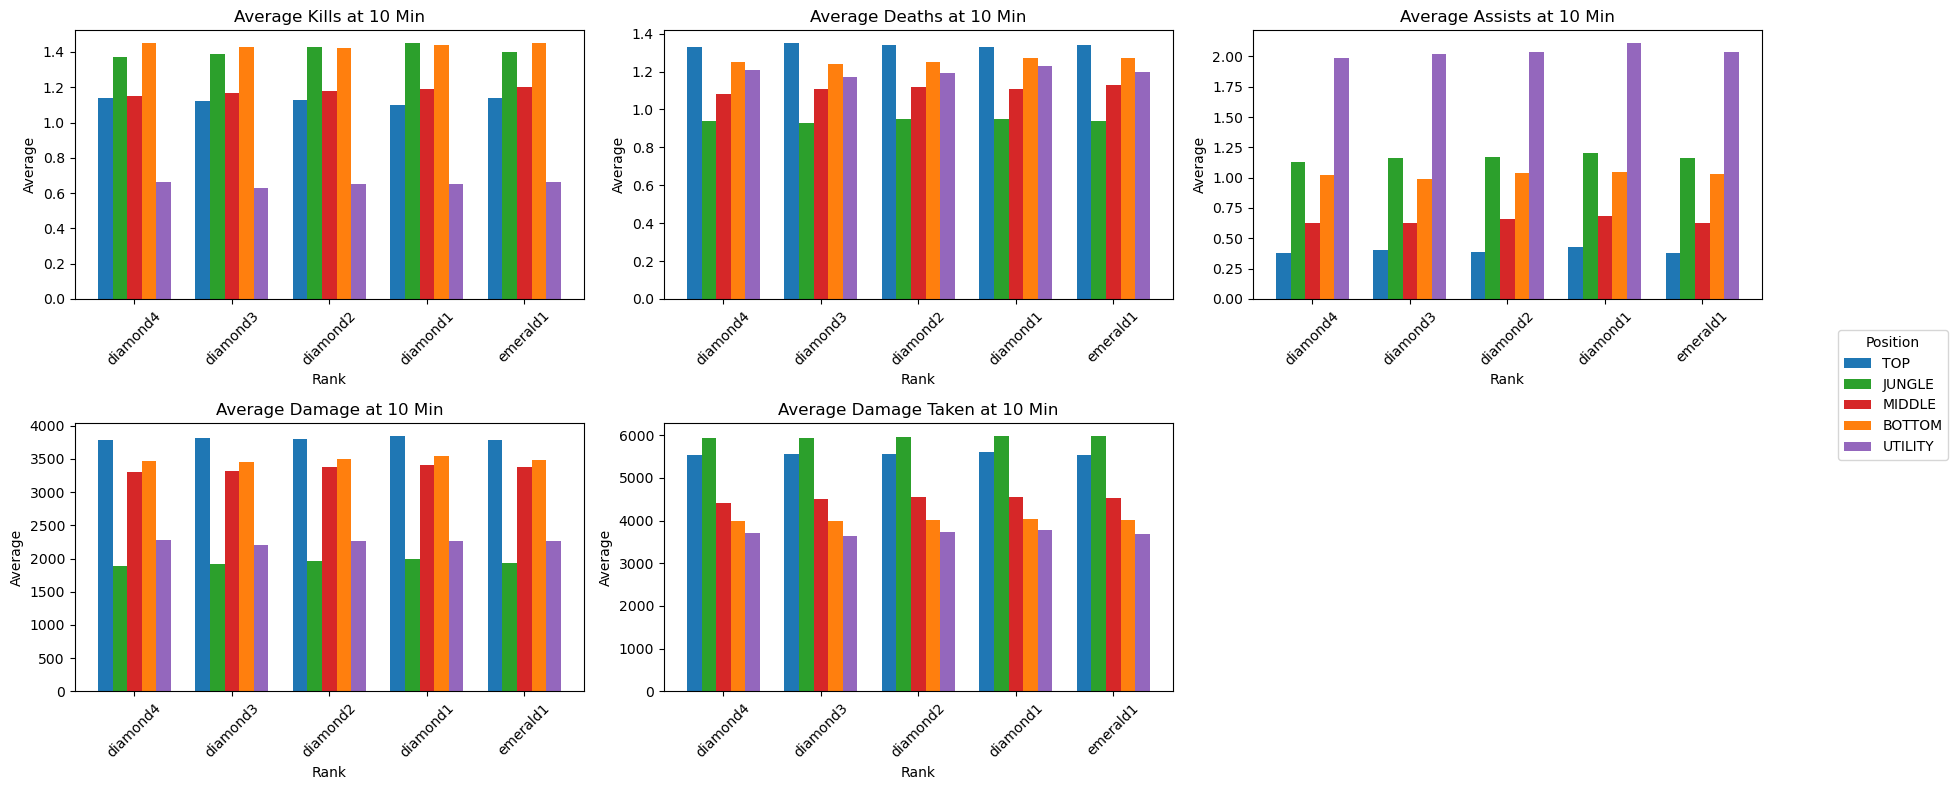

In [115]:
summary3 = plot_rank_position_metrics(
    combined,
    metrics=["kills_10min", "deaths_10min", "assists_10min", "damage_10min", "dmg_taken_per_min"],
    titles=[
        "Average Kills at 10 Min",
        "Average Deaths at 10 Min",
        "Average Assists at 10 Min",
        "Average Damage at 10 Min",
        "Average Damage Taken at 10 Min"
    ],
    scale_cols={"dmg_taken_per_min": 10}
)

These plots show clear role-based differences in early combat patterns, while differences across ranks remain fairly small. BOTTOM and JUNGLE have the highest average kills at 10 minutes, suggesting they are often the most involved in early skirmishes and ganks, whereas UTILITY has the fewest kills. For deaths at 10 minutes, TOP is the highest across all ranks, which may reflect the isolated and matchup-heavy nature of top lane, while JUNGLE tends to have the lowest deaths. UTILITY stands out by having by far the highest assists at 10 minutes, which makes sense because supports are heavily involved in team fights and lane trades without necessarily securing kills themselves.

For damage-related metrics, TOP has the highest damage dealt at 10 minutes, followed by BOTTOM and MIDDLE, while JUNGLE is much lower. At the same time, JUNGLE has the highest damage taken at 10 minutes, with TOP also very high, indicating that these two roles are often the most exposed in early fights or frontline situations. Overall, the patterns are highly consistent across all ranks, which suggests that early combat behavior is driven much more by position responsibilities than by rank differences.

### Combat Stats  V.S. Resource Stats

In [116]:
def correlation_combat_resource(df):
    cols = [
        "kills_10min", "deaths_10min", "assists_10min",
        "gold_10min", "cs_10min", "xp_10min",
        "xp_per_min", "gold_per_min", "cs_per_min"
    ]
    
    corr = df[cols].corr().round(3)
    return corr
corr_table = correlation_combat_resource(combined)
corr_table

,kills_10min,deaths_10min,assists_10min,gold_10min,cs_10min,xp_10min,xp_per_min,gold_per_min,cs_per_min
kills_10min,1.000,0.143,0.204,0.720,0.042,0.349,0.350,0.733,0.034
deaths_10min,0.143,1.000,0.252,0.219,-0.246,0.204,0.156,0.200,-0.259
assists_10min,0.204,0.252,1.000,0.372,-0.353,0.177,0.142,0.323,-0.363
gold_10min,0.720,0.219,0.372,1.000,0.256,0.640,0.638,0.971,0.230
cs_10min,0.042,-0.246,-0.353,0.256,1.000,0.045,0.145,0.216,0.992
xp_10min,0.349,0.204,0.177,0.640,0.045,1.000,0.974,0.680,0.023
xp_per_min,0.350,0.156,0.142,0.638,0.145,0.974,1.000,0.684,0.141
gold_per_min,0.733,0.200,0.323,0.971,0.216,0.680,0.684,1.000,0.204
cs_per_min,0.034,-0.259,-0.363,0.230,0.992,0.023,0.141,0.204,1.000


In [117]:
import matplotlib.pyplot as plt

def plot_combat_resource_heatmap(df):
    cols = [
        "kills_10min", "deaths_10min", "assists_10min",
        "gold_10min", "cs_10min", "xp_10min",
        "xp_per_min", "gold_per_min", "cs_per_min"
    ]
    
    corr = df[cols].corr()
    
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr, aspect="auto")
    
    ax.set_xticks(range(len(cols)))
    ax.set_yticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=45, ha="right")
    ax.set_yticklabels(cols)
    
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
    
    ax.set_title("Correlation Between Combat and Resource Metrics")
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

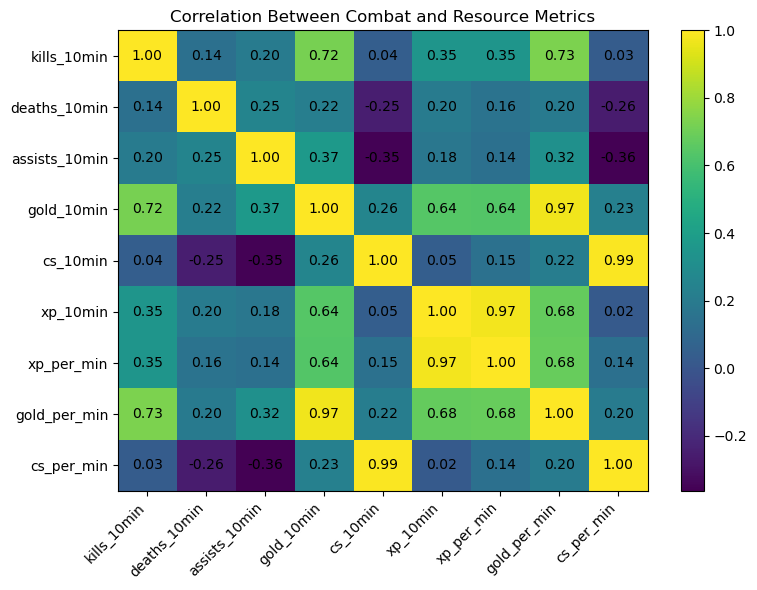

In [118]:
plot_combat_resource_heatmap(combined)

This heatmap shows the relationship between combat stats (kills, deaths, assists) and resource stats (gold, cs, xp). It also compares each-stage stats with overall stats. The strongest relationship is between kills_10min and both gold_10min (0.72) and gold_per_min (0.73), showing that early kills are closely tied to stronger gold generation. Kills also have a moderate positive relationship with xp_10min and xp_per_min (0.35 each), but almost no relationship with cs_10min (0.04) or cs_per_min (0.03). This suggests that early kills mainly help with gold and experience, but do not necessarily mean better farming.

Another clear pattern is that assists_10min and deaths_10min are both negatively related to CS, especially assists (-0.35 with cs_10min, -0.36 with cs_per_min) and deaths (-0.25 and -0.26). This implies that players who are more involved in fights, or die more often, tend to farm less efficiently. As expected, the same resource measures across scales are almost identical, such as gold_10min with gold_per_min (0.97), xp_10min with xp_per_min (0.97), and cs_10min with cs_per_min (0.99). Overall, this plot suggests that kills are the clearest combat indicator of early gold and XP advantage, while CS reflects a more farming-focused style that is relatively separate from direct combat involvement.

### Correlation with win

In [119]:
#
def position_win_correlation(df, position_name):
    pos_df = df[df["position"] == position_name].copy()
    
    team1 = pos_df[pos_df["team"] == "team1"][[
        "matchId", "win", "kills_10min", "gold_10min", "xp_10min"
    ]].copy()
    
    team2 = pos_df[pos_df["team"] == "team2"][[
        "matchId", "kills_10min", "gold_10min", "xp_10min"
    ]].copy()
    
    team1 = team1.rename(columns={
        "win": "win_team1",
        "kills_10min": "kills_team1",
        "gold_10min": "gold_team1",
        "xp_10min": "xp_team1"
    })
    
    team2 = team2.rename(columns={
        "kills_10min": "kills_team2",
        "gold_10min": "gold_team2",
        "xp_10min": "xp_team2"
    })
    
    merged = team1.merge(team2, on="matchId")
    
    merged["kill_diff"] = merged["kills_team1"] - merged["kills_team2"]
    merged["gold_diff"] = merged["gold_team1"] - merged["gold_team2"]
    merged["xp_diff"] = merged["xp_team1"] - merged["xp_team2"]
    
    corr_table = merged[["win_team1", "kill_diff", "gold_diff", "xp_diff"]].corr().round(3)
    
    result = pd.DataFrame({
        "position": [position_name, position_name, position_name],
        "metric": ["kill_diff", "gold_diff", "xp_diff"],
        "correlation_with_win": [
            corr_table.loc["win_team1", "kill_diff"],
            corr_table.loc["win_team1", "gold_diff"],
            corr_table.loc["win_team1", "xp_diff"]
        ]
    })
    
    return result, merged

In [120]:
top_result, _ = position_win_correlation(combined, "TOP")
jungle_result, _ = position_win_correlation(combined, "JUNGLE")
middle_result, _ = position_win_correlation(combined, "MIDDLE")
bottom_result, _ = position_win_correlation(combined, "BOTTOM")
utility_result, _ = position_win_correlation(combined, "UTILITY")

position_corr_summary = pd.concat(
    [top_result, jungle_result, middle_result, bottom_result, utility_result],
    ignore_index=True
)

position_corr_summary

,position,metric,correlation_with_win
0,TOP,kill_diff,0.149
1,TOP,gold_diff,0.169
2,TOP,xp_diff,0.166
3,JUNGLE,kill_diff,0.184
4,JUNGLE,gold_diff,0.223
5,JUNGLE,xp_diff,0.199
6,MIDDLE,kill_diff,0.181
7,MIDDLE,gold_diff,0.222
8,MIDDLE,xp_diff,0.192
9,BOTTOM,kill_diff,0.214


This table suggests that the relationship between early role-specific advantages and winning differs by position, but gold_diff is the strongest signal in every role. Among all positions, BOTTOM gold_diff has the highest correlation with win (0.251), followed by JUNGLE gold_diff (0.223) and MIDDLE gold_diff (0.222). This suggests that an early gold lead in these carry-heavy roles is more closely tied to match outcome than the same lead in TOP or UTILITY.

The same general pattern appears for kill_diff and xp_diff, though their correlations are slightly weaker than gold. BOTTOM also has the highest values for kills and XP, while UTILITY kill_diff is by far the weakest (0.080), which makes sense because support roles are less defined by securing kills. Overall, the results suggest that early advantages in BOTTOM, JUNGLE, and MIDDLE are more strongly associated with winning, while TOP and especially UTILITY have a weaker direct relationship with match outcome.

# Team Stats

Review team dataframe

In [121]:
print(d1_team.shape)
print(d1_team.columns.tolist())
d1_team.head()

(3966, 18)
['win', 'matchId', 'team100_kills_10min', 'team200_kills_10min', 'team100_deaths_10min', 'team200_deaths_10min', 'kill_diff_10min', 'kills_100', 'kills_200', 'kill_diff', 'first_blood_team100', 'jungle_own_100', 'jungle_enemy_100', 'jungle_own_200', 'jungle_enemy_200', 'jungle_invade_diff', 'gold_diff_10min', 'xp_diff_10min']


,win,matchId,team100_kills_10min,team200_kills_10min,team100_deaths_10min,team200_deaths_10min,kill_diff_10min,kills_100,kills_200,kill_diff,first_blood_team100,jungle_own_100,jungle_enemy_100,jungle_own_200,jungle_enemy_200,jungle_invade_diff,gold_diff_10min,xp_diff_10min
0,0,NA1_5464658841,7,5,5,7,2,7,5,2,0,2,1,1,0,1,718,991
1,1,NA1_5489233670,2,10,10,2,-8,2,10,-8,0,0,0,0,1,-1,-3030,-979
2,0,NA1_5502986727,6,10,10,6,-4,6,10,-4,0,0,0,0,2,-2,-2231,-8
3,0,NA1_5505235731,3,5,5,3,-2,3,5,-2,0,0,0,1,3,-3,-1372,-1826
4,1,NA1_5508890187,3,4,4,3,-1,3,4,-1,1,2,2,0,0,2,1047,405


In [122]:
# merge dataframes from all ranks
d1_team["rank"] = "diamond1"
d2_team["rank"] = "diamond2"
d3_team["rank"] = "diamond3"
d4_team["rank"] = "diamond4"
e1_team["rank"] = "emerald1"

all_teams = pd.concat([d1_team, d2_team, d3_team, d4_team, e1_team], ignore_index=True)

rank_order = ["diamond4", "diamond3", "diamond2", "diamond1", "emerald1"]
all_teams["rank"] = pd.Categorical(all_teams["rank"], categories=rank_order, ordered=True)

all_teams.head()

,win,matchId,team100_kills_10min,team200_kills_10min,team100_deaths_10min,team200_deaths_10min,kill_diff_10min,kills_100,kills_200,kill_diff,first_blood_team100,jungle_own_100,jungle_enemy_100,jungle_own_200,jungle_enemy_200,jungle_invade_diff,gold_diff_10min,xp_diff_10min,rank
0,0,NA1_5464658841,7,5,5,7,2,7,5,2,0,2,1,1,0,1,718,991,diamond1
1,1,NA1_5489233670,2,10,10,2,-8,2,10,-8,0,0,0,0,1,-1,-3030,-979,diamond1
2,0,NA1_5502986727,6,10,10,6,-4,6,10,-4,0,0,0,0,2,-2,-2231,-8,diamond1
3,0,NA1_5505235731,3,5,5,3,-2,3,5,-2,0,0,0,1,3,-3,-1372,-1826,diamond1
4,1,NA1_5508890187,3,4,4,3,-1,3,4,-1,1,2,2,0,0,2,1047,405,diamond1


We only kept the difference-based team variables for kills and death because the raw team100 and team200 values are perfectly mirrored, so using the differences removes redundancy and focuses directly on the competitive gap between the two teams.

In [123]:
team_diff = all_teams[[
    "matchId", "rank", "win",
    "kill_diff_10min",
    "jungle_own_100", "jungle_own_200",
    "jungle_invade_diff",
    "gold_diff_10min", "xp_diff_10min",
    "first_blood_team100"
]].copy()


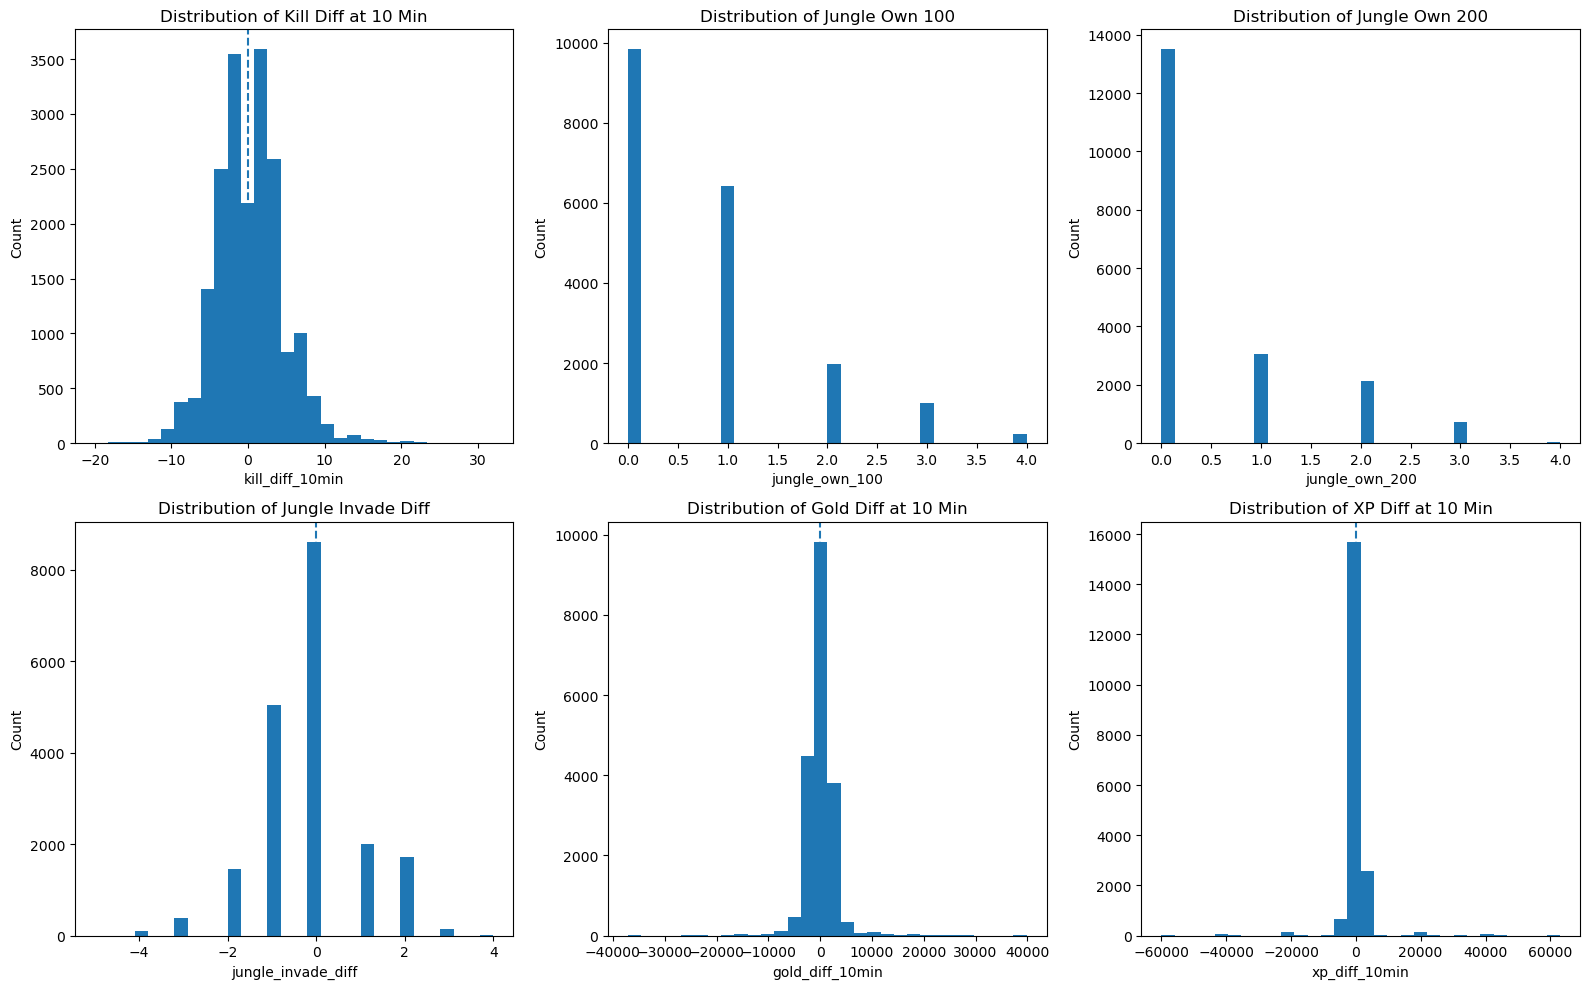

In [124]:
metrics = [
    "kill_diff_10min",
    "jungle_own_100",
    "jungle_own_200",
    "jungle_invade_diff",
    "gold_diff_10min",
    "xp_diff_10min"
]

titles = [
    "Distribution of Kill Diff at 10 Min",
    "Distribution of Jungle Own 100",
    "Distribution of Jungle Own 200",
    "Distribution of Jungle Invade Diff",
    "Distribution of Gold Diff at 10 Min",
    "Distribution of XP Diff at 10 Min"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, metric, title in zip(axes, metrics, titles):
    ax.hist(team_diff[metric].dropna(), bins=30)
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_ylabel("Count")
    
    if "diff" in metric:
        ax.axvline(0, linestyle="--")

plt.tight_layout()
plt.show()

These histograms show that most team-level difference variables are centered close to zero, which suggests that many matches are relatively balanced in the early game. Kill_diff_10min, gold_diff_10min, and xp_diff_10min all have their highest concentration around zero, but they also show long tails on both sides, meaning some matches develop much larger early advantages. Among them, gold and XP differences appear especially concentrated near zero with a few extreme outliers, while kill_diff_10min has a wider and more continuous spread.

The jungle-related variables have a more discrete distribution. Jungle_own_100 and jungle_own_200 are heavily concentrated at low integer values, with most observations near 0 or 1, while jungle_invade_diff is strongly centered at 0 and falls off quickly in both directions. This suggests that jungle invade advantages are usually small and less variable than kill, gold, or XP differences. Overall, the distributions reinforce the earlier results: most games start fairly even, but a smaller number of matches show clear early resource or combat gaps.

A brife summary of dataframe we will use to find the relationship between these features

In [125]:
team_diff.describe().round(2)

,win,kill_diff_10min,jungle_own_100,jungle_own_200,jungle_invade_diff,gold_diff_10min,xp_diff_10min,first_blood_team100
count,19464.00,19464.00,19464.00,19464.00,19464.00,19464.00,19464.00,19464.00
mean,0.51,0.21,0.73,0.50,-0.19,37.95,48.73,0.49
std,0.50,4.34,0.92,0.85,1.14,2991.11,5044.08,0.50
min,0.00,-20.00,0.00,0.00,-5.00,-37095.00,-60000.00,0.00
25%,0.00,-3.00,0.00,0.00,-1.00,-1271.00,-959.00,0.00
50%,1.00,0.00,0.00,0.00,0.00,-7.50,-2.00,0.00
75%,1.00,3.00,1.00,1.00,0.00,1248.00,932.25,1.00
max,1.00,32.00,4.00,4.00,4.00,39883.00,63000.00,1.00


### Kill, Jungle, Gold, XP, and First Blood

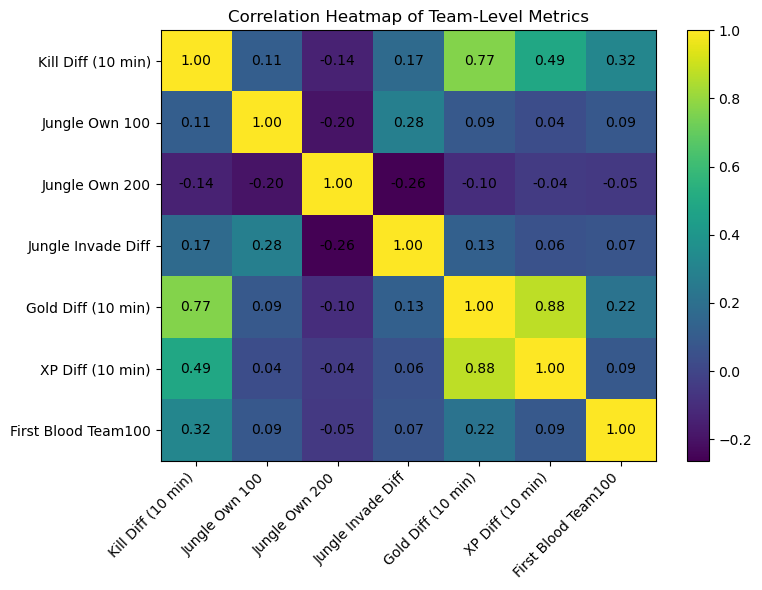

In [126]:
cols = [
    "kill_diff_10min",
    "jungle_own_100",
    "jungle_own_200",
    "jungle_invade_diff",
    "gold_diff_10min",
    "xp_diff_10min",
    "first_blood_team100"
]

labels = [
    "Kill Diff (10 min)",
    "Jungle Own 100",
    "Jungle Own 200",
    "Jungle Invade Diff",
    "Gold Diff (10 min)",
    "XP Diff (10 min)",
    "First Blood Team100"
]

corr = team_diff[cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, aspect="auto")

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

ax.set_title("Correlation Heatmap of Team-Level Metrics")
plt.colorbar(im)
plt.tight_layout()
plt.show()

This heatmap shows that gold_diff_10min is the central early-game advantage variable. It has a strong positive correlation with kill_diff_10min (0.77) and an even stronger correlation with xp_diff_10min (0.88), suggesting that teams with more early kills usually also build clear gold and experience leads. Kill_diff_10min also has a moderate positive relationship with xp_diff_10min (0.49) and first_blood_team100 (0.32), which is reasonable since early kills and first blood often happen together and first blood will provide extra gold.
In contrast, the jungle variables have much weaker relationships with the other early-game metrics. Jungle_own_100, jungle_own_200, and jungle_invade_diff show only small correlations with kill, gold, and XP differences, suggesting that jungle control in this form is less directly tied to the main early lead indicators. Overall, the plot suggests that kills, gold, and XP advantages tend to move together, while jungle-related measures and first blood appear to capture smaller or more separate parts of early-game dynamics.

For the rank comparison plots, we use absolute values of the difference variables so the charts reflect the size of the team gap rather than which specific team is ahead.

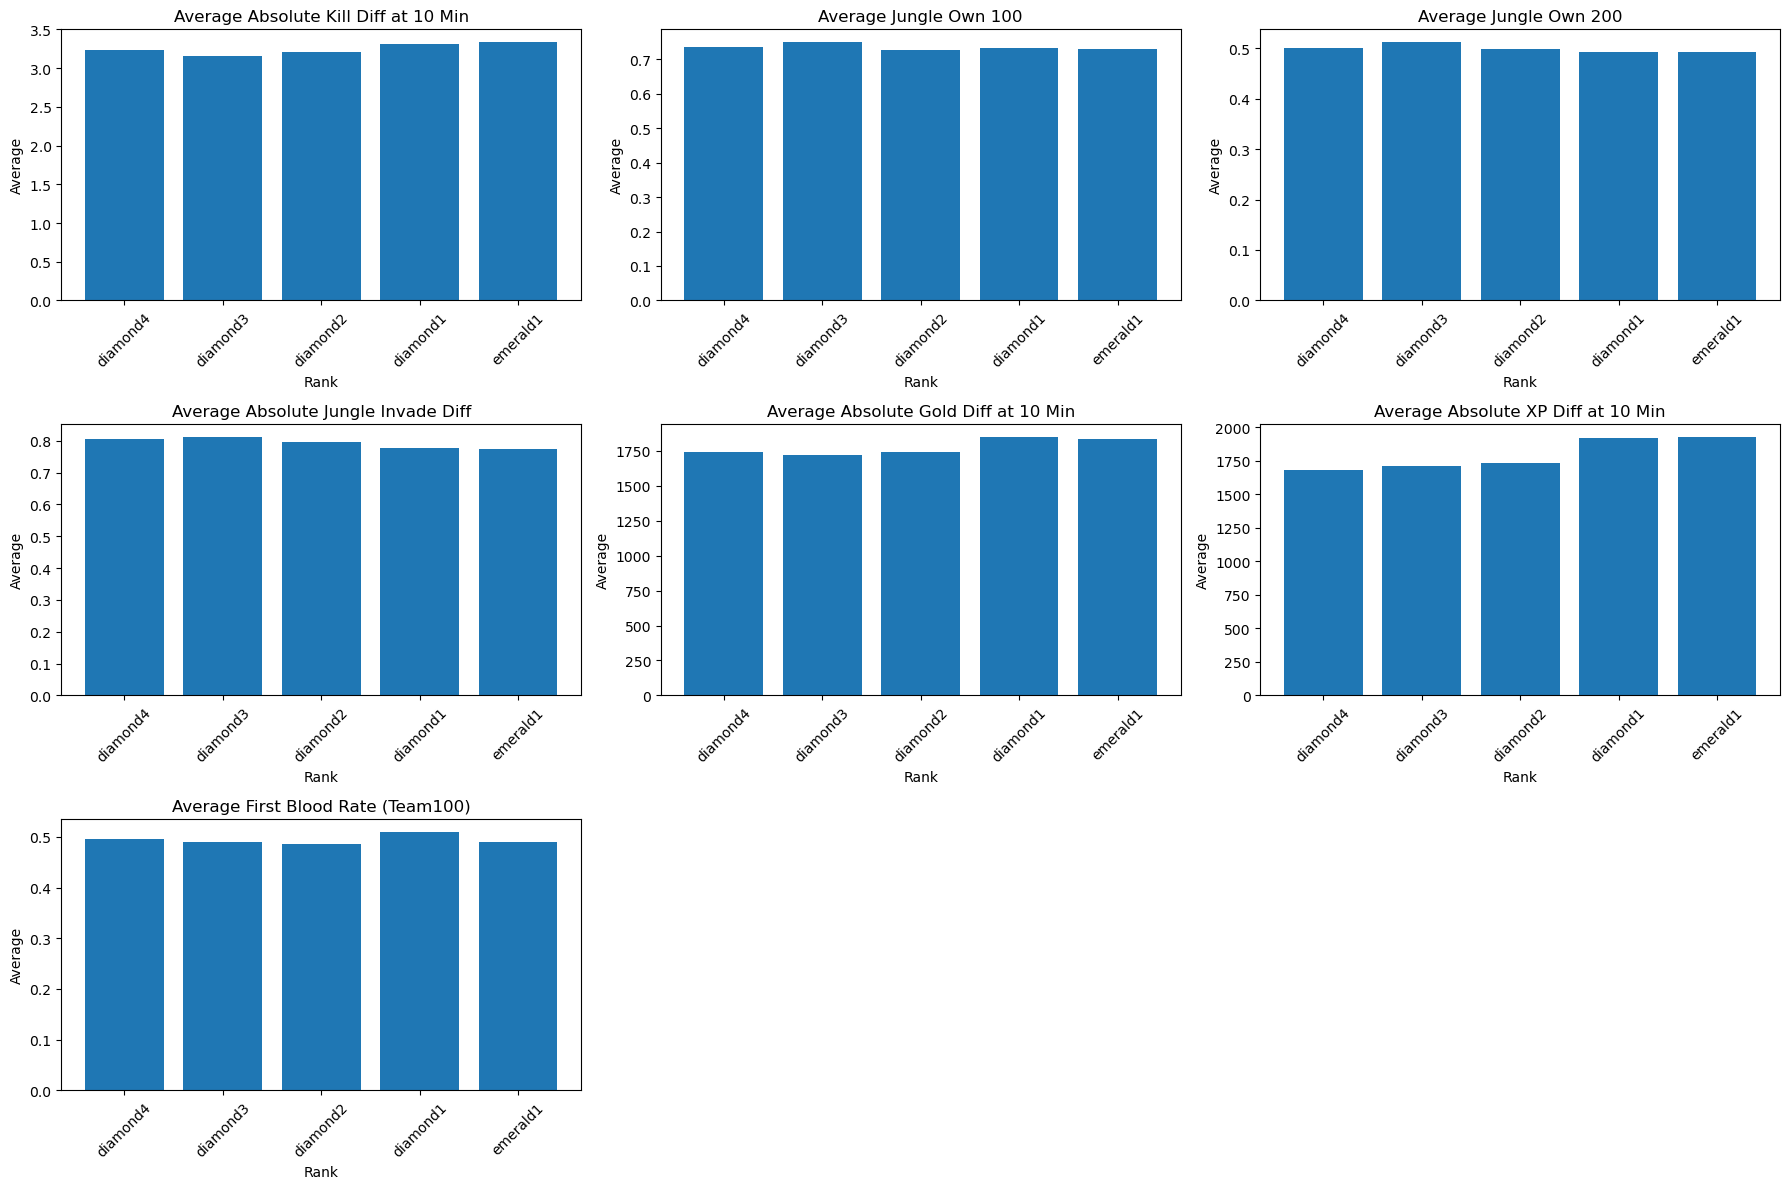

In [127]:
rank_order = ["diamond4", "diamond3", "diamond2", "diamond1", "emerald1"]

team_gap = team_diff.copy()
team_gap["kill_diff_10min"] = team_gap["kill_diff_10min"].abs()
team_gap["jungle_invade_diff"] = team_gap["jungle_invade_diff"].abs()
team_gap["gold_diff_10min"] = team_gap["gold_diff_10min"].abs()
team_gap["xp_diff_10min"] = team_gap["xp_diff_10min"].abs()

metrics = [
    "kill_diff_10min",
    "jungle_own_100",
    "jungle_own_200",
    "jungle_invade_diff",
    "gold_diff_10min",
    "xp_diff_10min",
    "first_blood_team100"
]

titles = [
    "Average Absolute Kill Diff at 10 Min",
    "Average Jungle Own 100",
    "Average Jungle Own 200",
    "Average Absolute Jungle Invade Diff",
    "Average Absolute Gold Diff at 10 Min",
    "Average Absolute XP Diff at 10 Min",
    "Average First Blood Rate (Team100)"
]

rank_summary = (
    team_gap.groupby("rank")[metrics]
    .mean()
    .reindex(rank_order)
)

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, metric, title in zip(axes, metrics, titles):
    ax.bar(rank_summary.index, rank_summary[metric])
    ax.set_title(title)
    ax.set_xlabel("Rank")
    ax.set_ylabel("Average")
    ax.tick_params(axis="x", rotation=45)

for i in range(len(metrics), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

These bar charts suggest that early team-level gaps are fairly stable across ranks, with only small differences overall. The average absolute kill difference and absolute jungle invade difference stay very similar from Emerald 1 through Diamond 4, which suggests that the general level of early fighting and invade pressure does not change much across these ranks. The same pattern appears for jungle_own_100, jungle_own_200, and first blood rate, all of which remain quite consistent across rank groups.

The main difference appears in absolute gold_diff_10min and absolute xp_diff_10min, where Diamond 1 and Emerald 1 show slightly larger early resource gaps than the other ranks. This may suggest that while kill and jungle patterns are broadly similar, the conversion of early actions into measurable gold and XP advantages is somewhat larger in those ranks. Overall, though, rank-based differences are still modest, so early team gap patterns look relatively consistent across the five rank levels.

### Correlation with Win

Win is included in the heatmap now

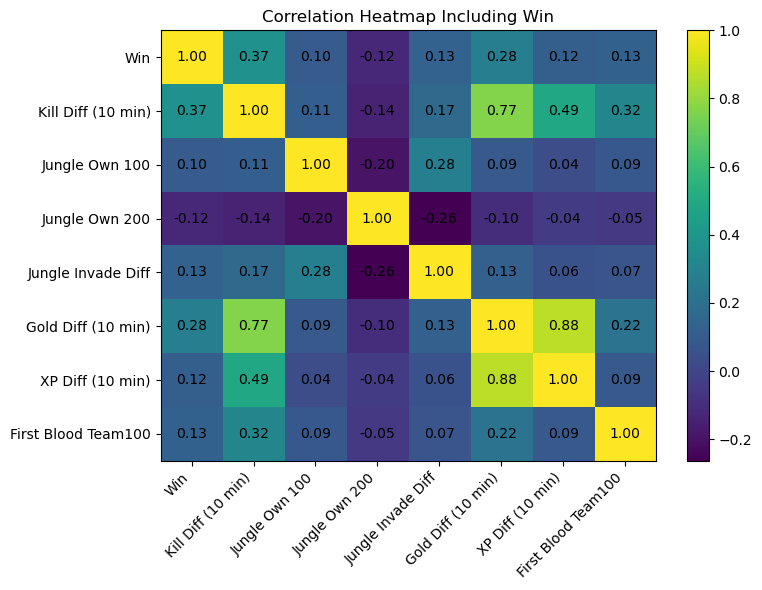

In [128]:
cols = [
    "win",
    "kill_diff_10min",
    "jungle_own_100",
    "jungle_own_200",
    "jungle_invade_diff",
    "gold_diff_10min",
    "xp_diff_10min",
    "first_blood_team100"
]

labels = [
    "Win",
    "Kill Diff (10 min)",
    "Jungle Own 100",
    "Jungle Own 200",
    "Jungle Invade Diff",
    "Gold Diff (10 min)",
    "XP Diff (10 min)",
    "First Blood Team100"
]

corr = team_diff[cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, aspect="auto")

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

ax.set_title("Correlation Heatmap Including Win")
plt.colorbar(im)
plt.tight_layout()
plt.show()

This heatmap shows that kill_diff_10min has the strongest relationship with win (0.37), followed by gold_diff_10min (0.28). The other variables, including first blood, jungle own, and jungle invade diff, have noticeably weaker correlations with winning. This suggests that among the early team-level features here, early kill advantage is the clearest signal of match outcome, with gold lead also playing an important role.

It also shows that the team features themselves are strongly connected. In particular, gold_diff_10min is highly correlated with xp_diff_10min (0.88) and kill_diff_10min (0.77), which means these early advantages often happen together. Overall, this plot gives a cleaner summary than the bar charts because it shows both the relationship with win and the relationships among the early-game variables in one place.